In [69]:
#IMPORTING LIBS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score



In [70]:
# Load Dataset

df = pd.read_csv("/content/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [71]:
#Dataset Information
print("Shape :", df.shape)

df.info()

df.describe()

Shape : (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   in

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [72]:
# Check Missing Values

missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [73]:
# Numerical Columns

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical Columns

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_494/1760191817.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_494/1760191817.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

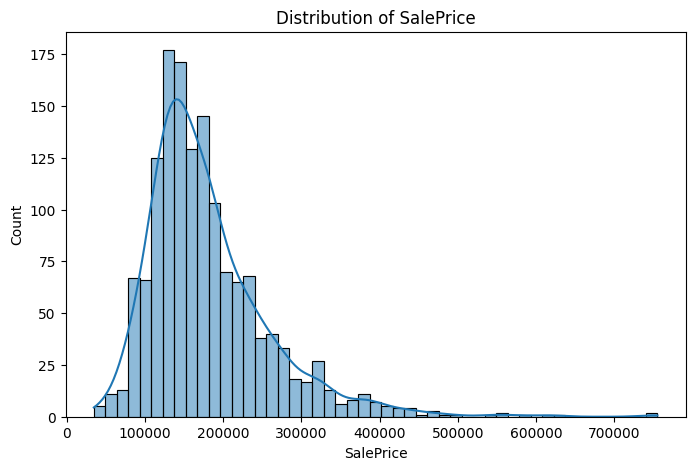

In [90]:
#Check Target Variable
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution of SalePrice")

plt.show()

In [75]:
#Remove ID Column
df.drop("Id", axis=1, inplace=True)

In [76]:
#One-Hot Encoding
df = pd.get_dummies(df, drop_first=True)

print(df.shape)

(1460, 245)


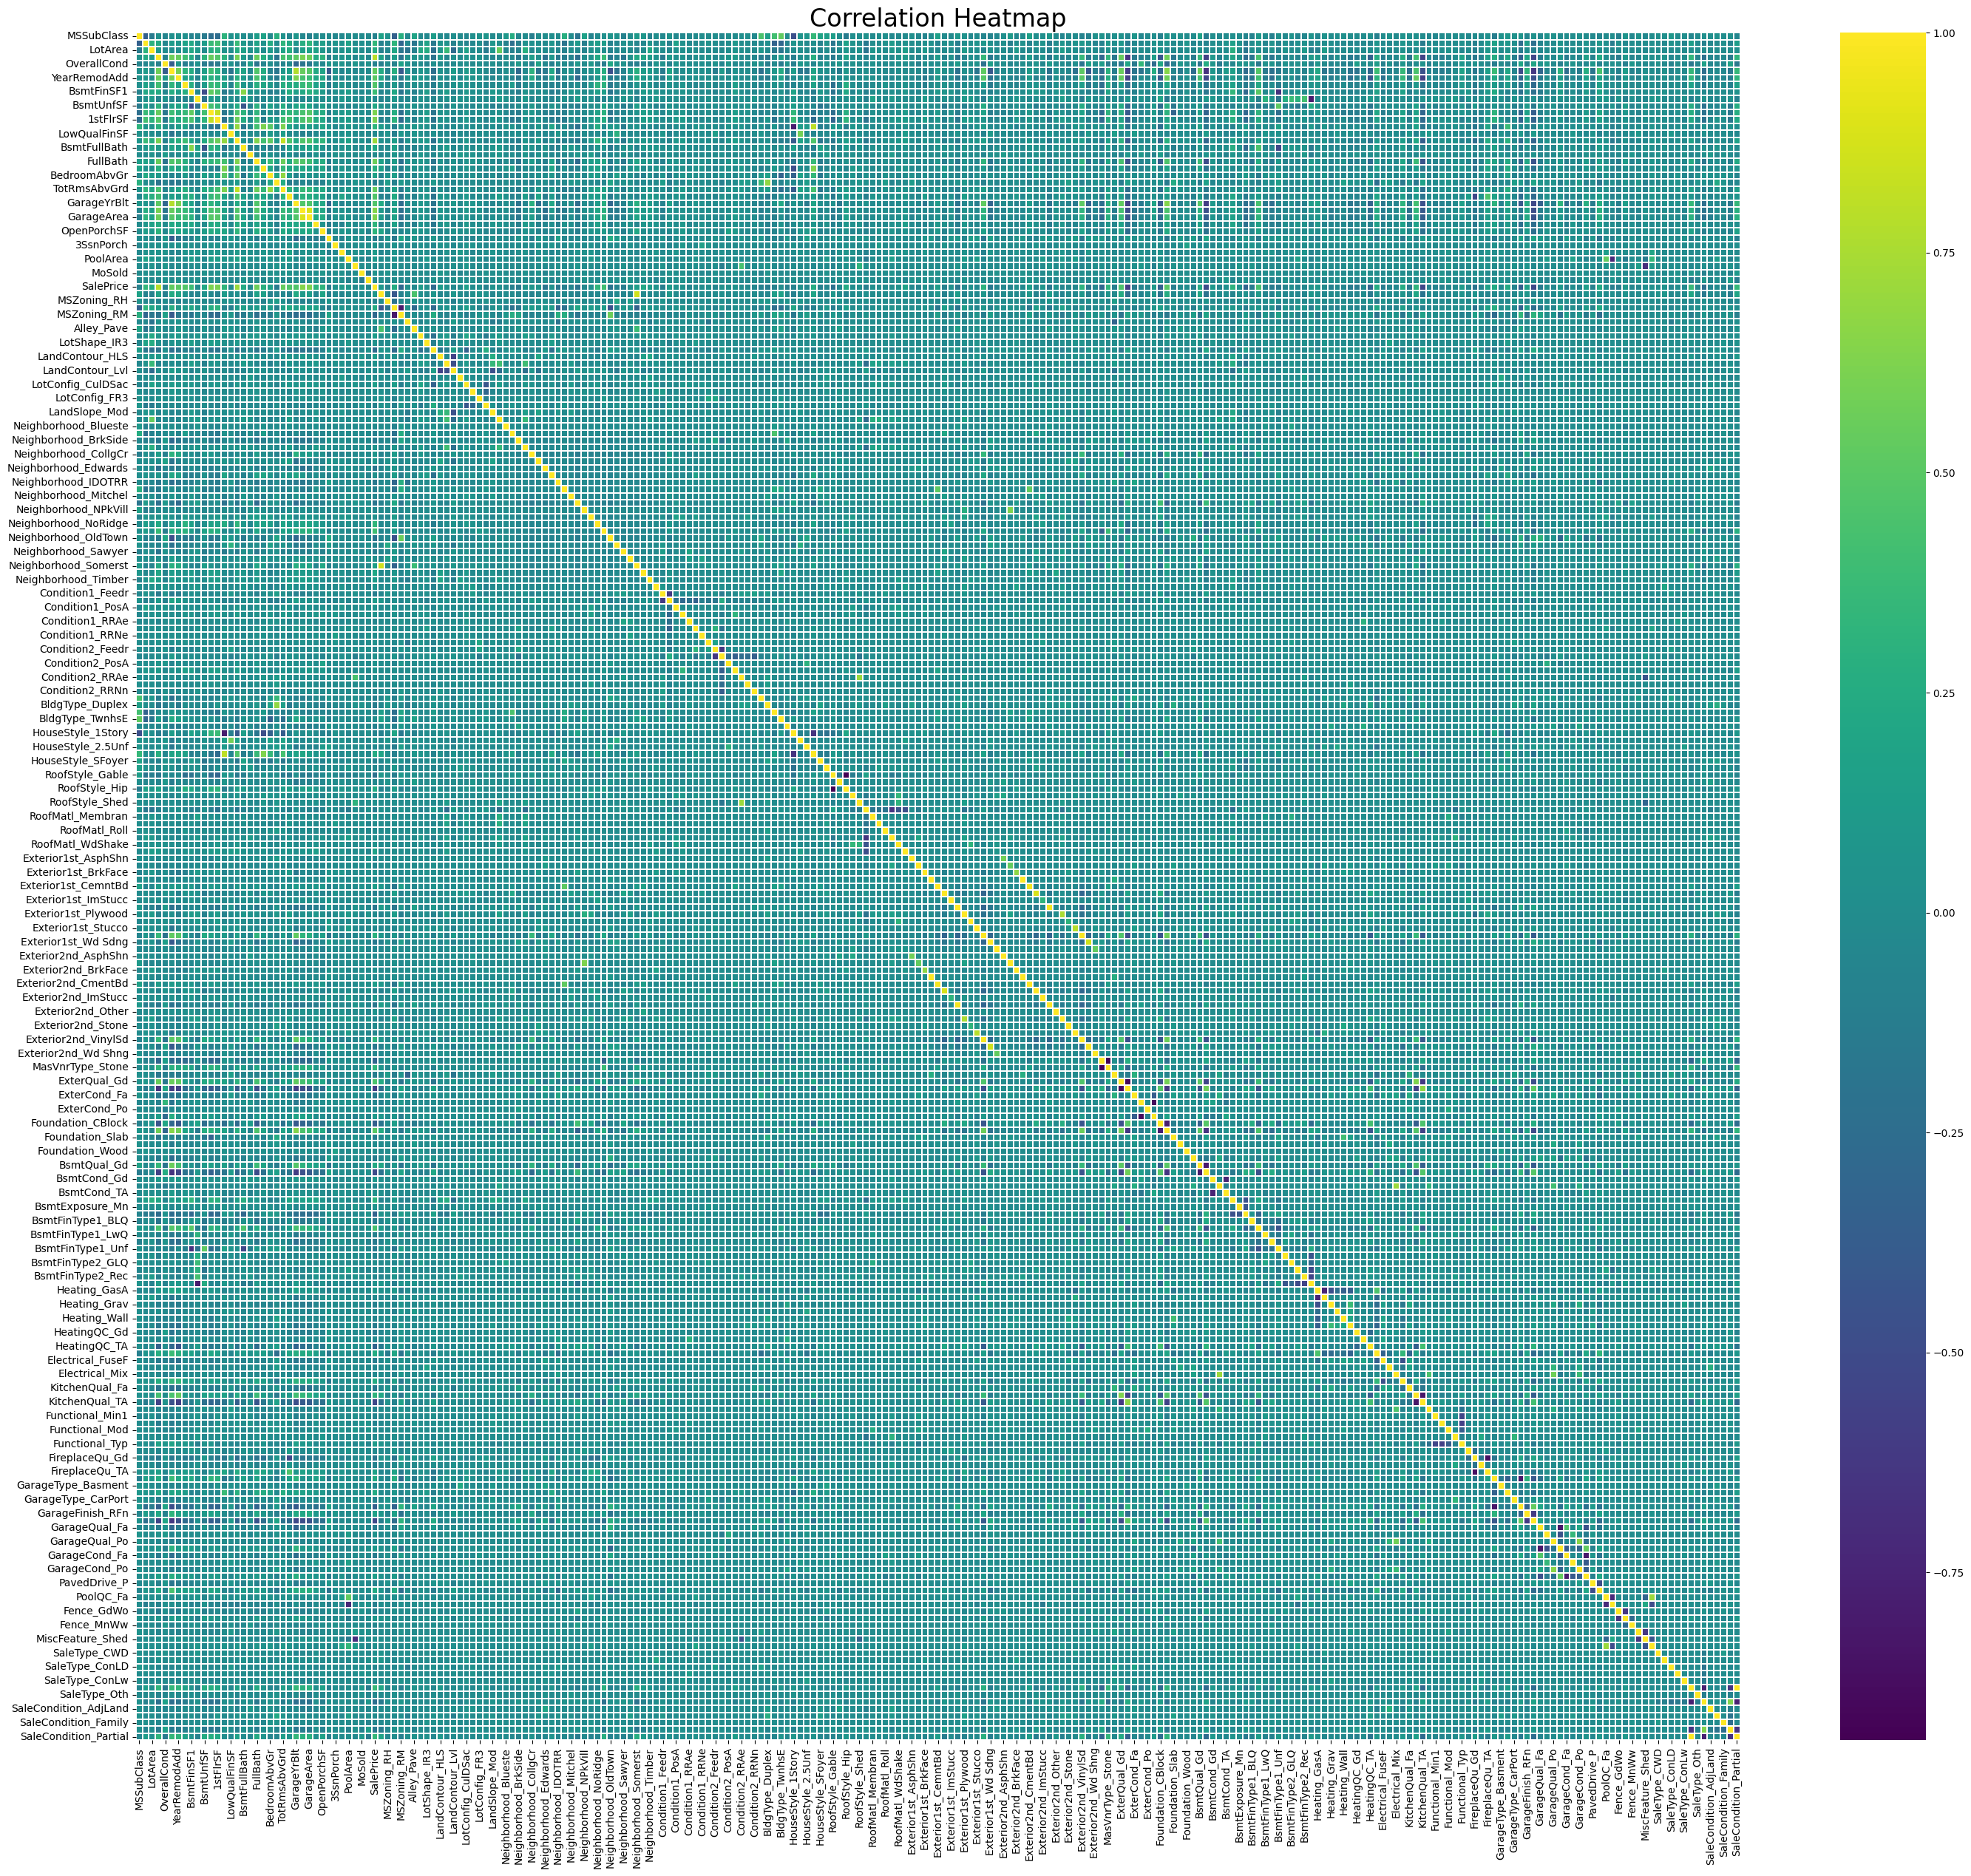

In [77]:
#Correlation Heatmap
plt.figure(figsize=(35,30))

sns.heatmap(
    df.corr(),
    cmap="viridis",
    linewidths=0.2
)

plt.title("Correlation Heatmap", fontsize=24)

plt.show()

In [78]:
#Top Features Related to SalePrice
corr = df.corr()

top_corr = corr["SalePrice"].sort_values(ascending=False)

print(top_corr.head(20))

SalePrice               1.000000
OverallQual             0.790982
GrLivArea               0.708624
GarageCars              0.640409
GarageArea              0.623431
TotalBsmtSF             0.613581
1stFlrSF                0.605852
FullBath                0.560664
TotRmsAbvGrd            0.533723
YearBuilt               0.522897
YearRemodAdd            0.507101
Foundation_PConc        0.497734
MasVnrArea              0.472614
Fireplaces              0.466929
GarageYrBlt             0.466754
ExterQual_Gd            0.452466
BsmtFinType1_GLQ        0.434597
Neighborhood_NridgHt    0.402149
BsmtFinSF1              0.386420
SaleType_New            0.357509
Name: SalePrice, dtype: float64


In [79]:
#Feature and Target
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [80]:
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42
)

In [81]:
#Train Linear Regression
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [82]:
#Prediction
y_pred = model.predict(X_test)

In [83]:
#Evaluation
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MSE : 2641205374.230949
RMSE : 51392.65875814316
R2 Score : 0.6556593157985733


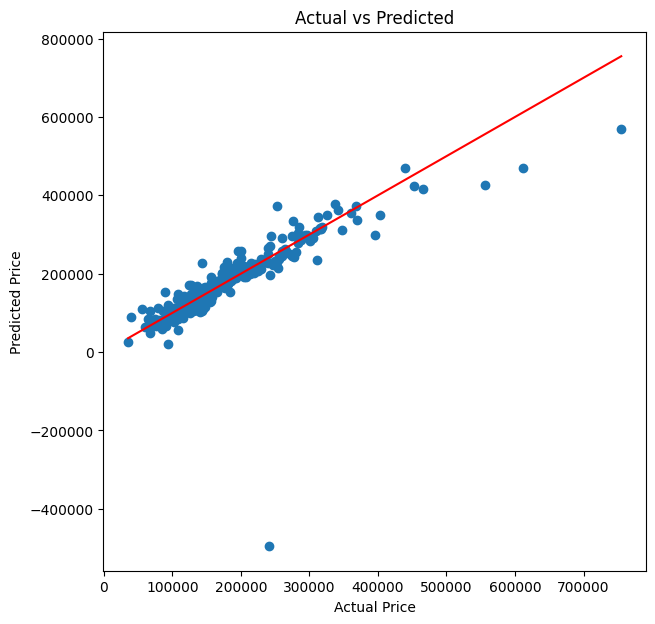

In [84]:
plt.figure(figsize=(7,7))

plt.scatter(y_test, y_pred)

plt.plot(

[y_test.min(), y_test.max()],

[y_test.min(), y_test.max()],

color="red"

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

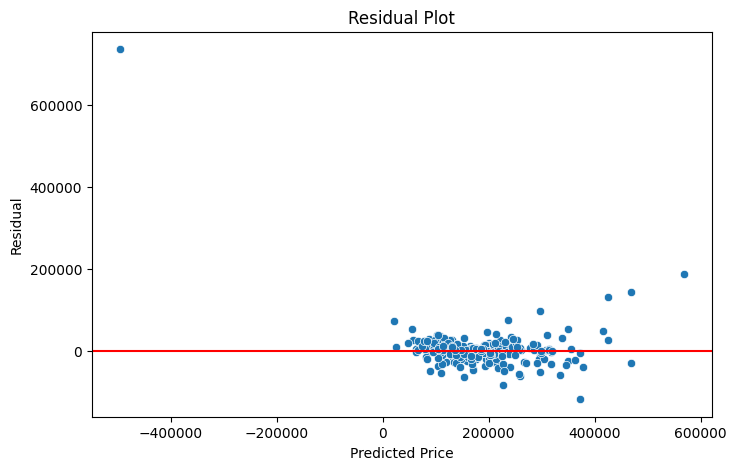

In [85]:
residual = y_test - y_pred

plt.figure(figsize=(8,5))

sns.scatterplot(x=y_pred, y=residual)

plt.axhline(0,color='red')

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [86]:
coef = pd.DataFrame({

    "Feature": X.columns,

    "Coefficient": model.coef_

})

coef.sort_values(by="Coefficient", ascending=False).head(15)

,Feature,Coefficient
112,RoofMatl_Metal,703481.026720
116,RoofMatl_WdShngl,668839.346946
114,RoofMatl_Tar&Grv,660271.426169
110,RoofMatl_CompShg,656521.518961
115,RoofMatl_WdShake,655688.000282
113,RoofMatl_Roll,655372.666794
220,GarageCond_TA,160176.426846
218,GarageCond_Gd,160050.247985
217,GarageCond_Fa,157137.515049
219,GarageCond_Po,154484.954398


In [87]:
ridge = Ridge(alpha=1)

ridge.fit(X_train,y_train)

ridge_pred = ridge.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test,ridge_pred))

ridge_r2 = r2_score(y_test,ridge_pred)

print("Ridge RMSE :", ridge_rmse)

print("Ridge R2 :", ridge_r2)

Ridge RMSE : 30513.74216569243
Ridge R2 : 0.8786116214872423


In [88]:
comparison = pd.DataFrame({

    "Model":["Linear Regression","Ridge"],

    "RMSE":[rmse,ridge_rmse],

    "R2 Score":[r2,ridge_r2]

})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,51392.658758,0.655659
1,Ridge,30513.742166,0.878612
